# Регрессия IC50

In [ ]:
!pip install xgboost -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split,
                                     RandomizedSearchCV)

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (mean_squared_error,
                             r2_score, mean_absolute_error)

In [ ]:
df = pd.read_csv('/content/df.csv')

In [ ]:
df.head()

,IC50,CC50,SI,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,MaxPartialCharge,...,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea,IC50_log,CC50_log,SI_log
0,6.239374,175.482382,28.125000,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,0.038844,...,0,0,0,0,0,3,0,1.979535,5.173221,3.371597
1,0.771831,5.402819,7.000000,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,0.012887,...,0,0,0,0,0,3,0,0.572014,1.856738,2.079442
2,223.808778,161.142320,0.720000,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,0.094802,...,0,0,0,0,0,3,0,5.415250,5.088474,0.542324
3,1.705624,107.855654,63.235294,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,0.038844,...,0,0,0,0,0,4,0,0.995333,4.690023,4.162553
4,107.131532,139.270991,1.300000,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,0.062897,...,0,0,0,0,0,0,0,4.683348,4.943576,0.832909


In [ ]:
df.shape

(969, 158)

### Проверим целесообразность использования _log версии таргета

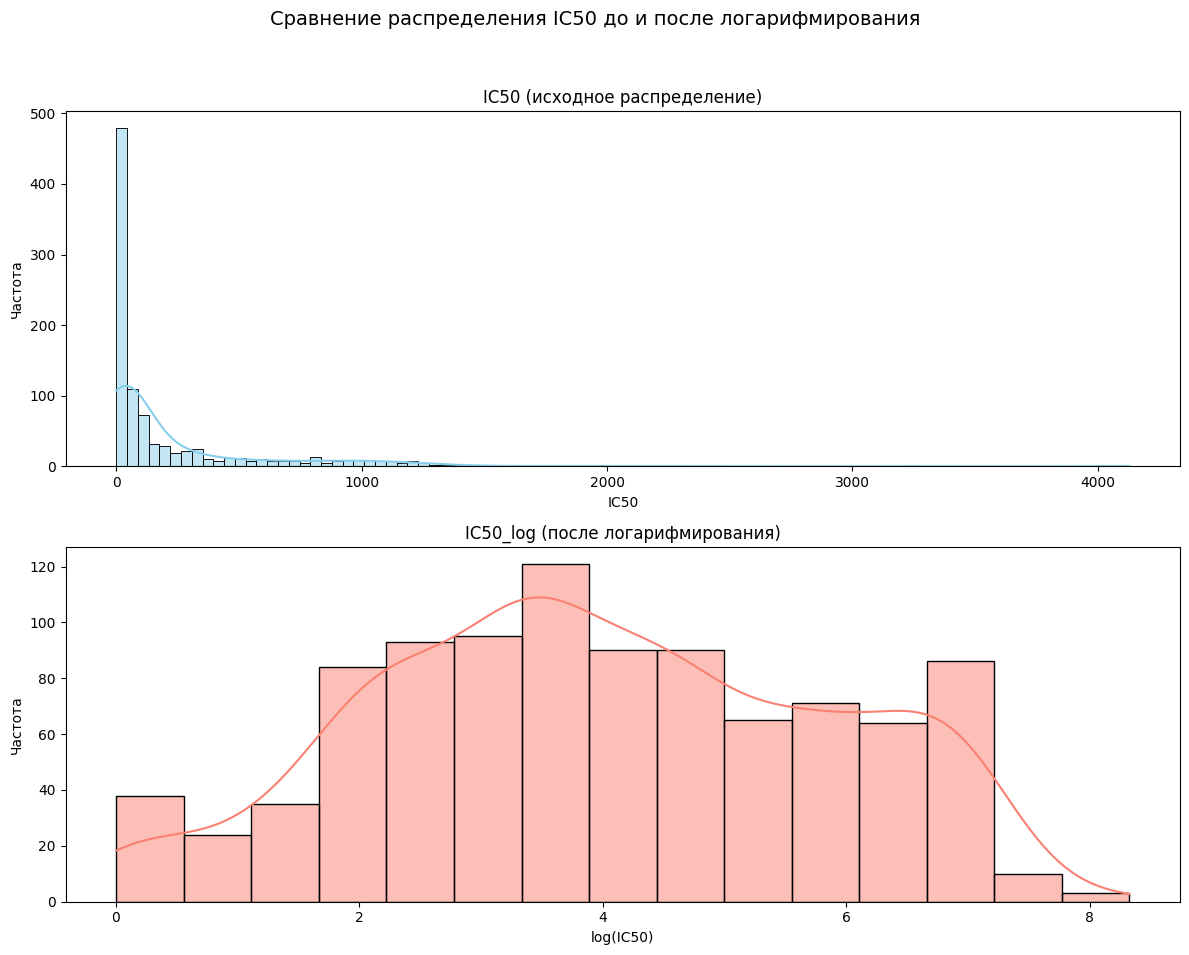

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# IC50
sns.histplot(
    df['IC50'],
    kde=True,
    ax=axes[0],
    color='skyblue'
)
axes[0].set_title('IC50 (исходное распределение)')
axes[0].set_xlabel('IC50')
axes[0].set_ylabel('Частота')

# IC50_log
sns.histplot(
    df['IC50_log'],
    kde=True,
    ax=axes[1],
    color='salmon'
)
axes[1].set_title('IC50_log (после логарифмирования)')
axes[1].set_xlabel('log(IC50)')
axes[1].set_ylabel('Частота')

plt.suptitle('Сравнение распределения IC50 до и после логарифмирования', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

IC50_log демонстрирует лучшее распределение, так что используем его

## Рассуждение
1. Биологический смысл связи
- IC50 измеряет ингибирование целевого процесса
- CC50 измеряет общую токсичность для клетки

Формально:
- ингибирование ≠ обязательно гибель клетки
- цитотоксичность = более тяжелый эффект

Поэтому верно:
- сильная цитотоксичность часто сопровождается низким IC50
- но низкий IC50 не обязан приводить к цитотоксичности

2. IC50, CC50, SI — это результаты биологических экспериментов
- дескрипторы молекулы обычно доступны до экспериментов
- если оставить CC50, модель будет использовать информацию, которую в реальном - сценарии предсказания новой молекулы ещё нельзя знать

### Проверим варианты с/без CC50

,Feature_Set,Model,RMSE,MAE,R²
0,No_CC50,XGBoost,1.350560,1.061347,0.505637
1,No_CC50,RandomForest,1.352389,1.084318,0.504297
2,No_CC50,LinearRegression,1.608022,1.321993,0.299188
3,With_CC50,XGBoost,1.167161,0.901458,0.630785
4,With_CC50,RandomForest,1.194530,0.920681,0.613267
5,With_CC50,LinearRegression,1.417721,1.193838,0.455247


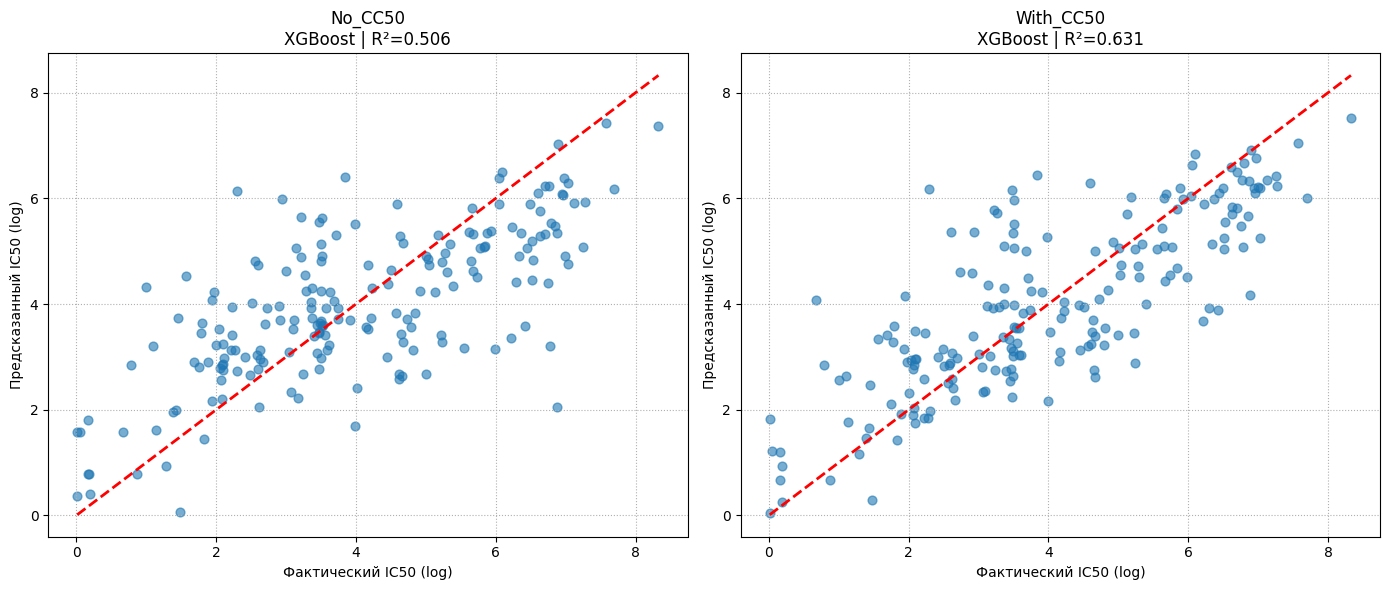

In [ ]:
y = df['IC50_log']

feature_sets = {
    'No_CC50': df.drop(
        columns=[
            'IC50', 'CC50', 'SI',
            'IC50_log', 'CC50_log', 'SI_log'],
        errors='ignore'),

    'With_CC50': df.drop(
        columns=[
            'IC50', 'SI',
            'IC50_log', 'CC50_log', 'SI_log'],
        errors='ignore')}

models = {
    'LinearRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.9)),
        ('model', LinearRegression())]),

    'RandomForest': RandomForestRegressor(
        random_state=42,
        n_jobs=-1),

    'XGBoost': XGBRegressor(
        random_state=42,
        n_jobs=-1)}

param_random = {
    'RandomForest': {
        'n_estimators': [200, 300, 500],
        'max_depth': [10, 20],
        'min_samples_split': [2, 4, 8],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 0.5, 0.8],
        'bootstrap': [True, False],},

    'XGBoost': {
        'n_estimators': [200, 300, 500],
        'max_depth': [3, 5, 7, 9],
        'learning_rate': [0.05, 0.1],
        'subsample': [0.7, 0.8, 1.0],
        'colsample_bytree': [0.7, 0.8, 1.0],
        'min_child_weight': [1, 3, 5]}}

results = []
best_models = {}

for fs_name, X in feature_sets.items():

    X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                        test_size=0.2,
                                                        random_state=42)

    for model_name, model in models.items():

        search = (
            RandomizedSearchCV(
                model,
                param_distributions=param_random[model_name],
                n_iter=10,
                cv=3,
                scoring='neg_root_mean_squared_error',
                n_jobs=-1,
                random_state=42)
            if model_name in param_random
            else None)

        if search is not None:
            search.fit(X_train, y_train)
            best_model = search.best_estimator_
        else:
            best_model = model.fit(X_train, y_train)

        y_pred = best_model.predict(X_test)

        results.append({
            'Feature_Set': fs_name,
            'Model': model_name,
            'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
            'MAE': mean_absolute_error(y_test, y_pred),
            'R²': r2_score(y_test, y_pred)})

        best_models[(fs_name, model_name)] = {
            'model': best_model,
            'X_test': X_test,
            'y_test': y_test}

results_df = (
    pd.DataFrame(results)
    .sort_values(
        ['Feature_Set', 'R²'],
        ascending=[True, False])
    .reset_index(drop=True))

display(results_df)

best_no_cc50 = (
    results_df
    .query("Feature_Set == 'No_CC50'")
    .iloc[0])

best_with_cc50 = (
    results_df
    .query("Feature_Set == 'With_CC50'")
    .iloc[0])

# +визуализация
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6))

for ax, row in zip(
    axes,
    [best_no_cc50, best_with_cc50]):

    model_info = best_models[
        (row['Feature_Set'], row['Model'])]

    model = model_info['model']
    X_test = model_info['X_test']
    y_test = model_info['y_test']

    y_pred = model.predict(X_test)

    lims = [
        min(y_test.min(), y_pred.min()),
        max(y_test.max(), y_pred.max())]

    ax.scatter(
        y_test,
        y_pred,
        alpha=0.6,
        s=40)

    ax.plot(
        lims,
        lims,
        'r--',
        linewidth=2)

    ax.set_title(
        f"{row['Feature_Set']}\n"
        f"{row['Model']} | R²={row['R²']:.3f}")

    ax.set_xlabel('Фактический IC50 (log)')
    ax.set_ylabel('Предсказанный IC50 (log)')
    ax.grid(True, linestyle=':')

plt.tight_layout()
plt.show()

### Прирост
- 0.63 - 0.51 = 0.12

То есть модель объясняет дополнительно около 12% дисперсии.

Это говорит о том, что:
- CC50 является очень информативным предиктором для IC50
- Модель активно использует эту информацию

Если цель:
- По дескрипторам новой молекулы предсказать IC50 - то CC50 удаляем, так как для новой молекулы CC50 ещё неизвестен.

Если цель:
- Предсказать IC50, имея результаты других экспериментов - то CC50 оставляем.

Тогда R² = 0.63 — честный результат.

### Вывод
Использование CC50 повышает качество прогноза IC50 с R²=0.51 до R²=0.63, что указывает на существенную взаимосвязь между показателями. Однако в итоговой модели признак CC50 был исключен, поскольку он представляет собой результат отдельного биологического эксперимента и не доступен в типовом сценарии прогнозирования активности новых соединений.

## Интерпретация результатов моделей
1. Наилучшее качество предсказания стабильно демонстрирует XGBoost, что указывает на наличие нелинейных зависимостей между дескрипторами и IC50.
2. RandomForest показывает сопоставимое качество, но немного уступает по объясняющей способности и стабильности.
3. LinearRegression существенно проигрывает, что подтверждает нелинейный характер задачи.

## Дополнительно:
- Переход к логарифмированному таргету уменьшает влияние выбросов и стабилизирует ошибку;
- Улучшение R² при использовании CC50 подтверждает наличие сильной корреляции между токсичностью и ингибиторной активностью.

# Итоговые выводы
1. Лучший результат достигнут моделью XGBoost на логарифмированном IC50 с R² ≈ 0.51 без использования CC50.
2. Добавление CC50 увеличивает качество до R² ≈ 0.63, что подтверждает сильную связь между цитотоксичностью и ингибиторной активностью.
3. Однако использование CC50 ограничено сценарием применения и может приводить к утечке данных при прогнозировании новых молекул.
4. Таким образом, итоговая модель без CC50 является более корректной с точки зрения практического применения, несмотря на более низкий R².